In [11]:
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
from sam.dataset import generate_dual_task_batch, generate_dual_task_batch_fast, get_distributions

from configurations import load_data, set_font_sizes, create_fig, apply_general_styles, save_fig, make_params_dict
from configurations.plot_config import FONTSIZES

from dashboard.data_manager import get_new_data_matrix , get_attn_patterns
import time

apply_general_styles()

# Test batch generation

In [4]:
vocab_size = 50

# Define device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

P_b, P_u, P_o, P_t = get_distributions(vocab_size, device=device,alpha=0.01,b_type='dirichlet',u_type='dirichlet',
                                       beta=0.5)

Using device: cuda
Sampling bigram distribution from a Dirichlet distribution with concentration parameter alpha =  0.01


In [10]:
batch_size = 100
L = 120
K = 15
trigget_set = np.arange(K).tolist()

t0 = time.time()
batch = generate_dual_task_batch_fast(batch_size,L,K,P_b,P_u,P_o,P_t,trigger_set=trigget_set)
t1 = time.time()


batch = generate_dual_task_batch(batch_size,L,K,P_b,P_u,P_o,P_t,trigger_set=trigget_set)
t3 = time.time()

t_fast = t1 - t0
t_slow = t3 - t1

speedup = t_slow / t_fast

print(f"Speedup: {speedup:.2f}x")

Speedup: 514.57x


In [11]:
batch_size = 100
L = 120
K = 15
trigget_set = np.arange(K).tolist()

t0 = time.time()
batch = generate_dual_task_batch_fast(batch_size,L,K,P_b,P_u,P_o,P_t,trigger_set=trigget_set,device=device)
t1 = time.time()


batch = generate_dual_task_batch(batch_size,L,K,P_b,P_u,P_o,P_t,trigger_set=trigget_set)
t3 = time.time()

t_fast = t1 - t0
t_slow = t3 - t1

speedup = t_slow / t_fast

print(f"Speedup: {speedup:.2f}x")

Speedup: 36.26x


In [9]:
import json
from dataclasses import dataclass , asdict
from typing import Optional

In [10]:
@dataclass
class ModelArgs:
    vocab_size: int = 64
    seq_len: int = 256
    d_model: int = 128
    dropout: float = 0.0
    K: int = 20

@dataclass
class OptimArgs:
    lr: float = 1e-3
    opt: str = "adam"
    momentum: float = 0.9
    weight_decay: float = 0.0

@dataclass
class DataArgs:
    batch_size: int = 64
    test_size: int = 200

@dataclass
class ExperimentArgs:
    experiment_name: str = "dual_task"
    steps: int = 600
    n_prints: int = 60
    n_prints_model: int = 6
    print_scale: str = "linear"
    init: str = "random"
    b_type: str = "dirichlet"
    u_type: str = "zipf"
    alpha: float = 1.0
    beta: float = 0.5
    fix_trig: bool = True
    trig_type: str = "freq"

@dataclass
class TrainerArgs:
    model_args: ModelArgs
    optim_args: OptimArgs
    data_args: DataArgs
    experiment_args: ExperimentArgs
    
# Initialize full config
trainer_args = TrainerArgs(
    model_args=ModelArgs(),
    optim_args=OptimArgs(),
    data_args=DataArgs(),
    experiment_args=ExperimentArgs()
)

# Convert the dataclass to a dictionary
trainer_args_dict = asdict(trainer_args)

# Save the dictionary to a JSON file
with open(f"../logs/{trainer_args.experiment_args.experiment_name}_config.json", "w") as f:
    json.dump(trainer_args_dict, f, indent=4)

In [7]:
trainer_args.__dict__

{'model_args': ModelArgs(vocab_size=64, seq_len=256, d_model=128, dropout=0.0, K=20),
 'optim_args': OptimArgs(lr=0.001, opt='adam', momentum=0.9, weight_decay=0.0),
 'data_args': DataArgs(batch_size=64, test_size=200),
 'experiment_args': ExperimentArgs(experiment_name='dual_task', steps=600, n_prints=60, n_prints_model=6, print_scale='linear', init='random', b_type='dirichlet', u_type='zipf', alpha=1.0, beta=0.5, fix_trig=True, trig_type='freq')}

# new metrics

In [24]:
path = ['full', 'induction', 'bigram'][0]
btype = ['dirichlet','spiked_dirichlet','spiked_zipf'][0]
K = [10,15,20][0]
# load from pickel file
with open(f"../data/dual_task_new/{btype}_{path}_K{K}_matrix.pkl", "rb") as f:
        results_matrix = pickle.load(f)
print(results_matrix.keys())
with open(f"../data/dual_task_new/{btype}_{path}_K{K}_scalar.pkl", "rb") as f:
        results = pickle.load(f)
print(results_matrix.keys())



print(results.keys())
print(results_matrix.keys())

dict_keys(['step', 'attn1', 'attn2', 'test_batch'])
dict_keys(['step', 'attn1', 'attn2', 'test_batch'])
dict_keys(['top1_accuracy', 'top3_accuracy', 'loss_total', 'loss_bigram', 'loss_ind', 'kl_b_total', 'kl_b_bigram', 'logit_std_total', 'logit_std_bigram', 'logit_std_induction', 'step', 'pop_loss_dual', 'pop_loss_induction', 'pop_loss_bigram', 'trigg_per_seq', 'kl_Pb_uniform', 'kl_Pu_uniform', 'entropy_Pb', 'entropy_Pu', 'max_entropy', 'exp_config'])
dict_keys(['step', 'attn1', 'attn2', 'test_batch'])


In [13]:
attn1, attn2, correct_attn, steps = get_attn_patterns(results_matrix, batch_id=0)

print(attn1.shape, attn2.shape, correct_attn.shape, steps)

shapes of test batch components: 
trigg_set: torch.Size([10]), out_set: torch.Size([10]), seq: torch.Size([256]), is_trigg: torch.Size([256]), counts: torch.Size([256])
Attention patterns loaded with shapes: att1 (10, 256, 256), att2 (10, 256, 256)
(10, 256, 256) (10, 256, 256) (10, 256) [  0 111 222 333 444 555 666 777 888 999]


Text(0.5, 0.98, 'dirichlet full K=10')

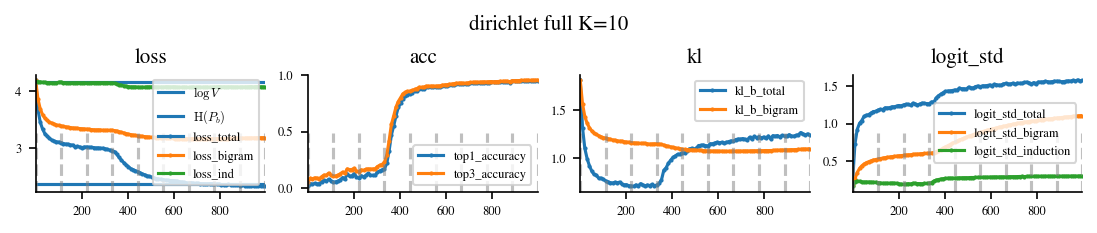

In [25]:
# Settings

set_font_sizes(conf='tight')

fig , axes = create_fig(ncols=4,size='double',h=0.2)

steps = results['step']


axes[0].axhline(results['max_entropy'],label=r'$\log V$')
axes[0].axhline(results['entropy_Pb'],label=r'$\mathrm{H}(P_b)$')


for i , tag in enumerate(['loss','acc','kl','logit_std']):
    ax = axes[i]
    for key in results:
        if tag in key and len(results[key].shape) == 1:
            # print(key,len(results[key].shape))
            ax.plot(steps, results[key], label=key,marker='.',markersize=2)
    ax.set_title(tag)
    ax.legend()
    for t in results_matrix['step']:
        ax.axvline(t, color='gray', linestyle='--', alpha=0.5,ymax=0.5)
ax.set_xlim(steps[0]+1, steps[-1])
# ax.set_xscale('log')
fig.suptitle(f"{btype} {path} K={K}")


tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([10, 35, 38, 54,  9,  3, 25, 22, 61, 22])
tensor([32, 51, 19,  2, 38, 60, 37,  2, 38, 17, 27, 19,  2, 38, 47, 13, 47, 13,
         6, 25, 16,  7, 22,  0, 10, 13, 17, 54, 16, 60, 37, 29,  9, 22, 55, 55,
        55,  1, 35, 10,  1, 35,  5,  3, 54, 11,  0, 10, 46, 37])
tensor([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
        0, 0])
tensor([1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 3, 3, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1,
        1, 3, 2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 3, 1, 1, 2, 2, 2, 1, 1, 2, 1, 2, 3,
        1, 3])


Text(0.5, 1.0, 'Attention from trigger to correct output')

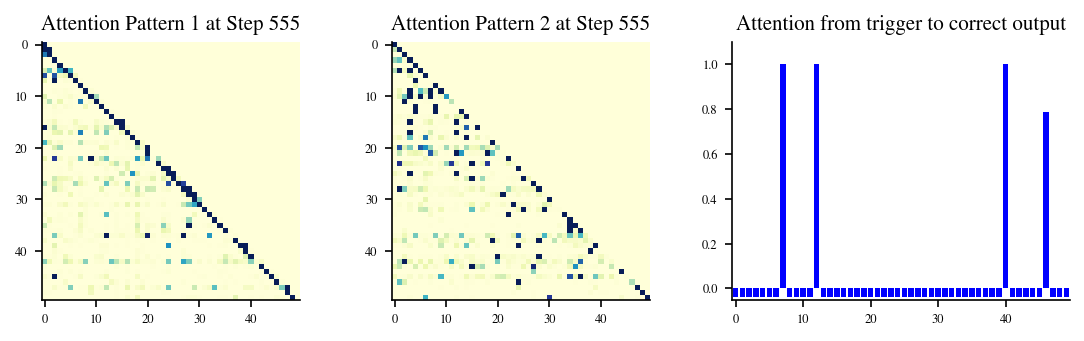

In [28]:
batch_id = 0
step_id = 5
cmap = 'YlGnBu'
lmin = 0
lmax = 50
fig , axes = create_fig(ncols=3,size='double',h=0.3)

trigg_set = results_matrix['test_batch']['trigger_set'][batch_id]
out_set = results_matrix['test_batch']['output_set'][batch_id]
seq = results_matrix['test_batch']['sequence'][batch_id][lmin:lmax]
is_trigg = results_matrix['test_batch']['is_trigg'][batch_id][lmin:lmax]
counts = results_matrix['test_batch']['counts'][batch_id][lmin:lmax]
# print(f"Trigger set for batch {batch_id}: {trigg_set}")
print(trigg_set)
print(out_set)
print(seq)
print(is_trigg)
print(counts)

for i , ax in enumerate(axes[:2]):
    att = results_matrix[f'attn{i+1}'][step_id,batch_id][lmin:lmax,lmin:lmax]
    im = ax.imshow(att, cmap=cmap,vmax=0.2)
    ax.set_title(f'Attention Pattern {i+1} at Step {results_matrix["step"][step_id]}')
    # fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# Compute the total attention from trigger tokens to the correct output tokens in the second pattern
correct_attention = np.zeros(len(seq))
for mu , tau in enumerate(seq):
    if is_trigg[mu] == 1 and counts[mu] > 1:
        # Map trigger tokens to their corresponding output tokens
        output_token = out_set[(trigg_set == tau).nonzero(as_tuple=True)[0].item()]
        # For the mu-th row of the attention pattern get the attention weigth of all output tokens and sum them up
        attention_weights = results_matrix[f'attn2'][step_id,batch_id][mu,lmin:lmax]
        correct_attention[mu] = attention_weights[seq == output_token].sum()
        # # Compute the total attention in second pattern from tau to output_token
        # total_attention = results_matrix[f'attn2'][step_id,batch_id][tau.item(),output_token.item()]
        # print(f"Trigger token {tau.item()} attends to output token {output_token.item()} with total attention {total_attention:.4f}")
    
    else:
        correct_attention[mu] = -0.04

ax = axes[2]
ax.bar(range(len(seq)), correct_attention, color='blue')
ax.set_ylim(-0.05,1.1)
ax.set_title('Attention from trigger to correct output')
